In [19]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import seaborn as sns

Panel A NIH3T3 Efficiency FDR trade off plot

Panel B: Simulation

In [27]:
res = pd.read_csv("sum_stats_all.csv")
grpd = res.groupby(["lvf", "nbarcodes", "nnonspec", "ims"])

reps_summed = grpd[["negative_control_barcodes", "fp", "total_true_cnts", "not_decoded_true", "gene_encoding_barcodes"]].agg(np.sum)
reps_summed["Sensitivity"] = (reps_summed.total_true_cnts - reps_summed.not_decoded_true)/reps_summed.total_true_cnts
reps_summed["False Discovery Rate"] = reps_summed.fp/(reps_summed.total_true_cnts+reps_summed.fp)
reps_summed['Estimated False Discovery Rate'] = (reps_summed.negative_control_barcodes*3334/4666)/reps_summed.gene_encoding_barcodes
reps_summed.reset_index(inplace=True)
reps_summed["Number of barcodes"] = reps_summed["nbarcodes"]
reps_summed["Average number of barcodes per pixel"] = reps_summed["nbarcodes"]/25
reps_summed["\nNumber of random dots"] = reps_summed["nnonspec"]
reps_summed["\nAverage number of non-specific dots per pixel"] = reps_summed["nnonspec"]/25
reps_summed["Group"] = reps_summed["ims"]
reps_summed.loc[reps_summed.ims == '_ims', "Group"] = "Simulated dot locations →\nsimulated images → ADCG → decoding"
reps_summed.loc[reps_summed.ims == '_no_ims', "Group"] = "Simulated dot locations → decoding"

#sns.relplot(data=reps_summed.loc[reps_summed.lvf == 6], x="False Discovery Rate" , y="Efficiency",hue='Number of barcodes', size='\nNumber of random dots', style="Group")

C:\Users\jonat\AppData\Local\Temp\ipykernel_6192\1553998666.py:4: FutureWarning: The provided callable <function sum at 0x000002924DBFC550> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  reps_summed = grpd[["negative_control_barcodes", "fp", "total_true_cnts", "not_decoded_true", "gene_encoding_barcodes"]].agg(np.sum)


In [28]:
np.unique(res.rep)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70], dtype=int64)

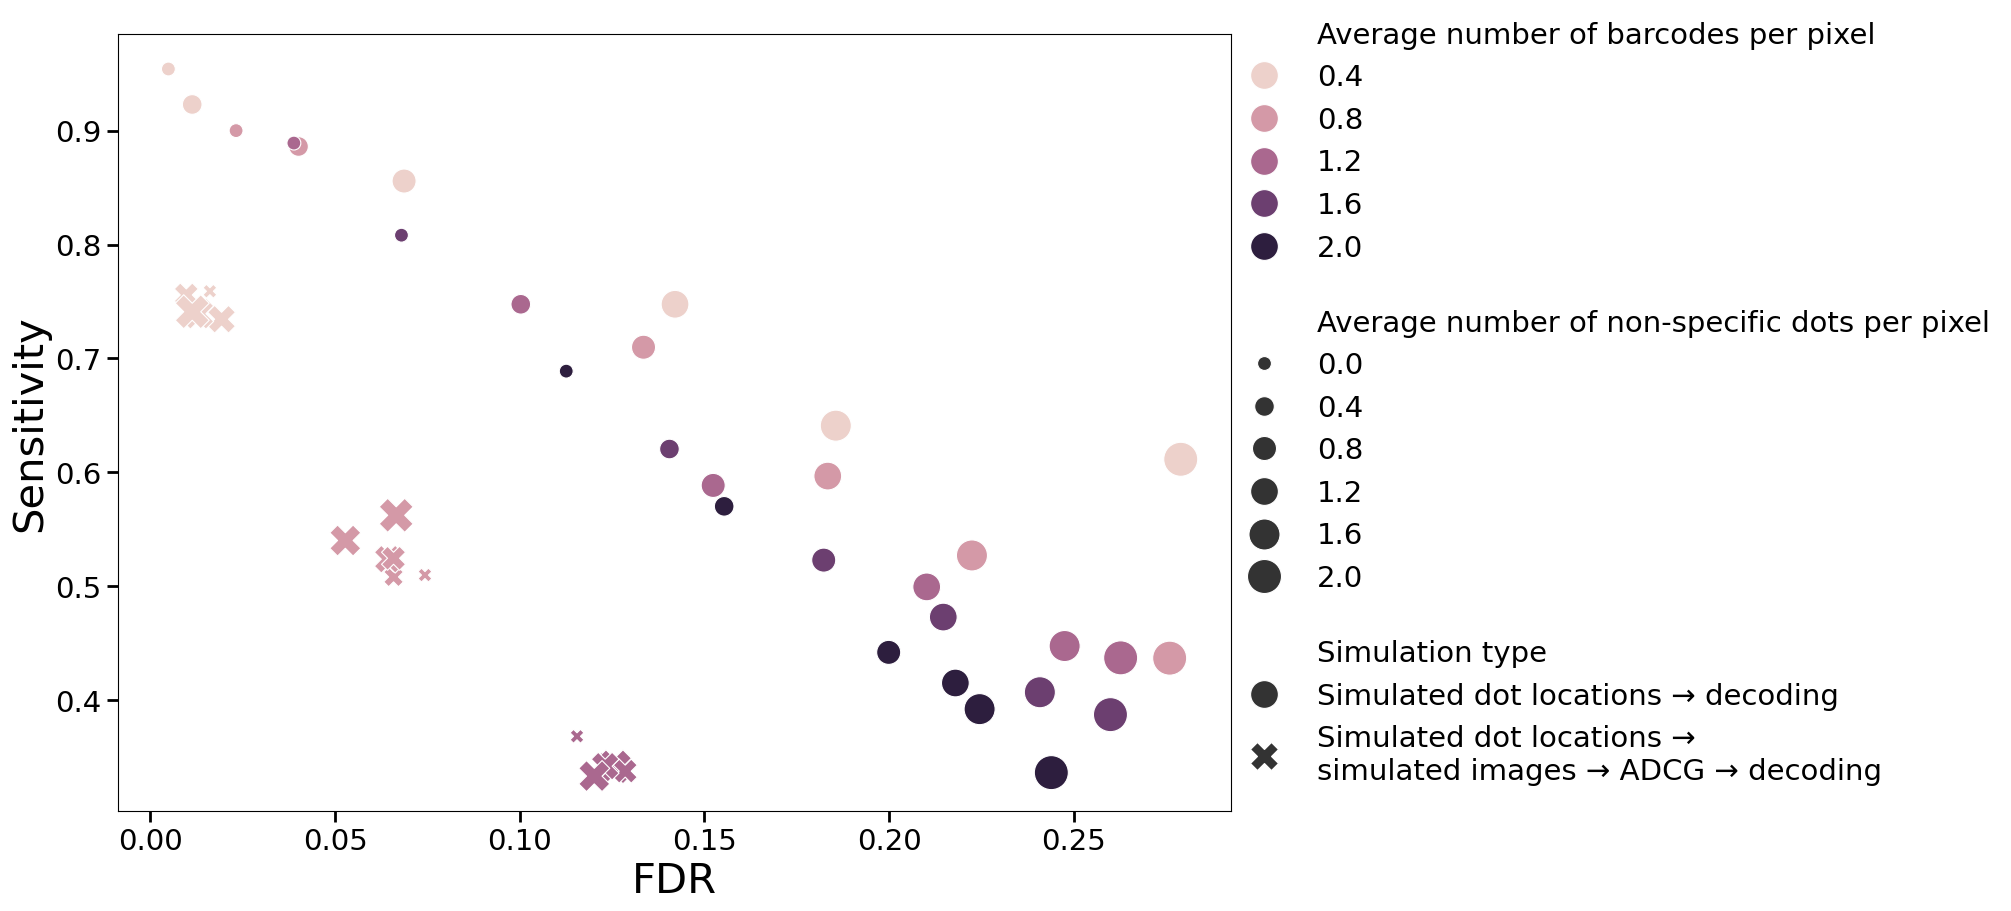

In [33]:

fig, axes = plt.subplots(1,1, figsize=(20,9), layout="constrained")

tick_width = 2
tick_length = 8
title_size=50
axis_label_size = 30
tick_label_size = 21
Panel_letter_size = 60
legend_font_size=21
marker_size_min = 100
marker_size_max = 600





axes.set_xlabel("Estimated FDR",fontsize=axis_label_size)

sim_ymin = 0.3
sim_ymax = 1.0

sims_with_img = reps_summed.loc[(reps_summed.lvf == 6) & (reps_summed.Group == "Simulated dot locations →\nsimulated images → ADCG → decoding")]
sims_no_img = reps_summed.loc[(reps_summed.lvf == 6) & (reps_summed.Group == "Simulated dot locations → decoding")]

reps_summed["\nSimulation type"] = reps_summed.Group
reps_summed.sort_values("\nSimulation type", inplace=True, ascending =False)

sns.scatterplot(data=reps_summed[reps_summed.lvf == 6], 
                x="False Discovery Rate" , 
                y="Sensitivity",
                hue='Average number of barcodes per pixel', #'Number of barcodes', 
                style="\nSimulation type", 
                size='\nAverage number of non-specific dots per pixel', #'\nNumber of random dots', 
                ax=axes, 
                sizes=(marker_size_min, marker_size_max)
               )



axes.set_xlabel("FDR", fontsize=axis_label_size)
axes.tick_params(axis="both",labelsize=tick_label_size, width=tick_width, length=tick_length)

axes.set_ylabel("Sensitivity", fontsize=axis_label_size)
handles, labels = axes.get_legend_handles_labels()

handles[1].set_markersize(20)
handles[2].set_markersize(20)
handles[3].set_markersize(20)
handles[4].set_markersize(20)
handles[5].set_markersize(20)
handles[6].set_markersize(20)

handles[-1].set_markersize(20)
handles[-2].set_markersize(20)
axes.legend(handles, labels, bbox_to_anchor = (0.98, 1.05), fontsize=legend_font_size,frameon=False)

plt.savefig("dots_1st_density_sim.jpg")